In [7]:
import pandas as pd
import numpy as np
import joblib, warnings, time
warnings.filterwarnings('ignore')

from sklearn.linear_model   import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.metrics         import (roc_auc_score, classification_report,
                                        confusion_matrix, RocCurveDisplay)
from xgboost                 import XGBClassifier
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')

In [8]:
# Load the processed splits saved in feature engineering
X_train   = pd.read_parquet('../data/processed/X_train.parquet')
X_val     = pd.read_parquet('../data/processed/X_val.parquet')
X_holdout = pd.read_parquet('../data/processed/X_holdout.parquet')
y_train   = pd.read_parquet('../data/processed/y_train.parquet').squeeze()
y_val     = pd.read_parquet('../data/processed/y_val.parquet').squeeze()
y_holdout = pd.read_parquet('../data/processed/y_holdout.parquet').squeeze()

# Scaled versions (for Logistic Regression)
X_train_sc   = pd.read_parquet('../data/features/X_train_scaled.parquet')
X_val_sc     = pd.read_parquet('../data/features/X_val_scaled.parquet')
X_holdout_sc = pd.read_parquet('../data/features/X_holdout_scaled.parquet')

# Class weight for imbalance
scale_pos = int((y_train == 0).sum() / (y_train == 1).sum())

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"scale_pos_weight: {scale_pos}")

X_train : (40837, 59)
X_val   : (10210, 59)
scale_pos_weight: 2


In [9]:
# Reusable evaluation function for all models
results = {}

def evaluate(name, model, X_tr, y_tr, X_v, y_v):
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = round(time.time() - t0, 2)

    y_prob_tr = model.predict_proba(X_tr)[:, 1]
    y_prob_v  = model.predict_proba(X_v)[:, 1]

    train_auc = round(roc_auc_score(y_tr, y_prob_tr), 4)
    val_auc   = round(roc_auc_score(y_v,  y_prob_v),  4)
    gap       = round(train_auc - val_auc, 4)

    results[name] = {'train_auc': train_auc, 'val_auc': val_auc,
                     'gap': gap, 'time_s': train_time, 'model': model}

    print(f"{name:<25} train={train_auc}  val={val_auc}  gap={gap}  ({train_time}s)")
    return model

In [10]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
evaluate('LogisticRegression', lr, X_train_sc, y_train, X_val_sc, y_val)

LogisticRegression        train=0.6225  val=0.6166  gap=0.0059  (2.07s)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [11]:
rf = RandomForestClassifier(
    n_estimators=200, class_weight='balanced',
    random_state=42, n_jobs=-1
)
evaluate('RandomForest', rf, X_train, y_train, X_val, y_val)

RandomForest              train=1.0  val=0.6574  gap=0.3426  (25.69s)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [12]:
xgb = XGBClassifier(
    n_estimators     = 500,
    learning_rate    = 0.05,
    max_depth        = 5,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = scale_pos,
    eval_metric      = 'auc',
    early_stopping_rounds = 30,
    random_state     = 42,
    verbosity        = 0
)

# XGBoost supports eval_set for early stopping
xgb.fit(X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False)

y_prob_xgb = xgb.predict_proba(X_val)[:, 1]
xgb_auc    = round(roc_auc_score(y_val, y_prob_xgb), 4)

results['XGBoost_default'] = {
    'val_auc': xgb_auc,
    'train_auc': round(roc_auc_score(y_train, xgb.predict_proba(X_train)[:,1]),4),
    'model': xgb
}
print(f"XGBoost default  val AUC: {xgb_auc}")
print(f"Best iteration  : {xgb.best_iteration}")

XGBoost default  val AUC: 0.6805
Best iteration  : 295


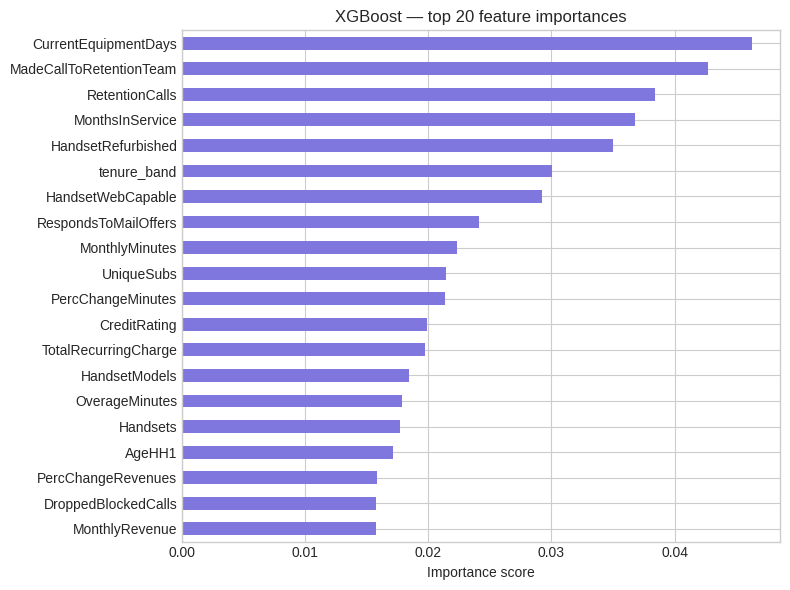

In [13]:
feat_imp = pd.Series(xgb.feature_importances_, index=X_train.columns)
top20    = feat_imp.nlargest(20)

fig, ax = plt.subplots(figsize=(8, 6))
top20.sort_values().plot(kind='barh', ax=ax, color='#7F77DD')
ax.set_title('XGBoost — top 20 feature importances')
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.show()

In [14]:
lgbm = lgb.LGBMClassifier(
    n_estimators     = 500,
    learning_rate    = 0.05,
    max_depth        = 5,
    num_leaves       = 31,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = scale_pos,
    random_state     = 42,
    verbose          = -1
)

lgbm.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(30, verbose=False),
               lgb.log_evaluation(-1)]
)

y_prob_lgbm = lgbm.predict_proba(X_val)[:, 1]
lgbm_auc    = round(roc_auc_score(y_val, y_prob_lgbm), 4)

results['LightGBM_default'] = {
    'val_auc': lgbm_auc,
    'train_auc': round(roc_auc_score(y_train, lgbm.predict_proba(X_train)[:,1]),4),
    'model': lgbm
}
print(f"LightGBM default val AUC: {lgbm_auc}")

LightGBM default val AUC: 0.65


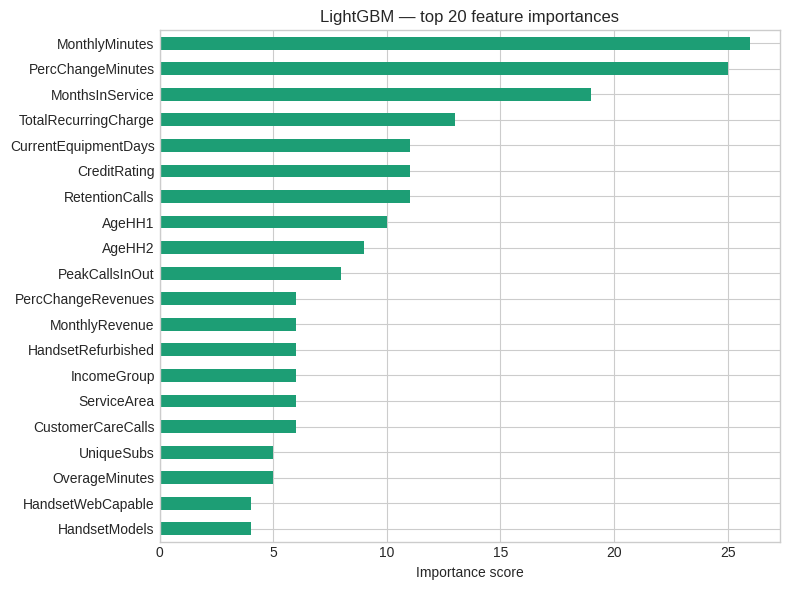

In [15]:
lgb_imp = pd.Series(lgbm.feature_importances_, index=X_train.columns)
top20_lgb = lgb_imp.nlargest(20)

fig, ax = plt.subplots(figsize=(8, 6))
top20_lgb.sort_values().plot(kind='barh', ax=ax, color='#1D9E75')
ax.set_title('LightGBM — top 20 feature importances')
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.show()

In [16]:
# Tune whichever model scored higher — here we tune XGBoost
def objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 200, 800),
        'max_depth'        : trial.suggest_int('max_depth', 3, 8),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'gamma'            : trial.suggest_float('gamma', 0, 1),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 0, 2),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 0, 2),
        'scale_pos_weight' : scale_pos,
        'eval_metric'      : 'auc',
        'verbosity'        : 0,
        'random_state'     : 42,
    }
    model = XGBClassifier(**params, early_stopping_rounds=20)
    model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)], verbose=False)
    y_prob = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, y_prob)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest val AUC : {study.best_value:.4f}")
print(f"Best params  : {study.best_params}")

Best trial: 29. Best value: 0.683775: 100%|██████████| 50/50 [23:03<00:00, 27.68s/it]


Best val AUC : 0.6838
Best params  : {'n_estimators': 722, 'max_depth': 6, 'learning_rate': 0.01583780489231885, 'subsample': 0.7394617535015974, 'colsample_bytree': 0.701287313717316, 'min_child_weight': 7, 'gamma': 0.3868044595091491, 'reg_alpha': 1.8820826672522986, 'reg_lambda': 1.9930254823764102}


In [17]:
best_params = study.best_params
best_params['scale_pos_weight'] = scale_pos
best_params['eval_metric']       = 'auc'
best_params['verbosity']         = 0
best_params['random_state']      = 42

best_model = XGBClassifier(**best_params, early_stopping_rounds=30)
best_model.fit(X_train, y_train,
               eval_set=[(X_val, y_val)], verbose=False)

y_prob_best = best_model.predict_proba(X_val)[:, 1]
best_auc    = round(roc_auc_score(y_val, y_prob_best), 4)

results['XGBoost_tuned'] = {'val_auc': best_auc, 'model': best_model}
print(f"Tuned XGBoost val AUC: {best_auc}")

Tuned XGBoost val AUC: 0.6838


             Model  Val AUC
     XGBoost_tuned   0.6838
   XGBoost_default   0.6805
      RandomForest   0.6574
  LightGBM_default   0.6500
LogisticRegression   0.6166


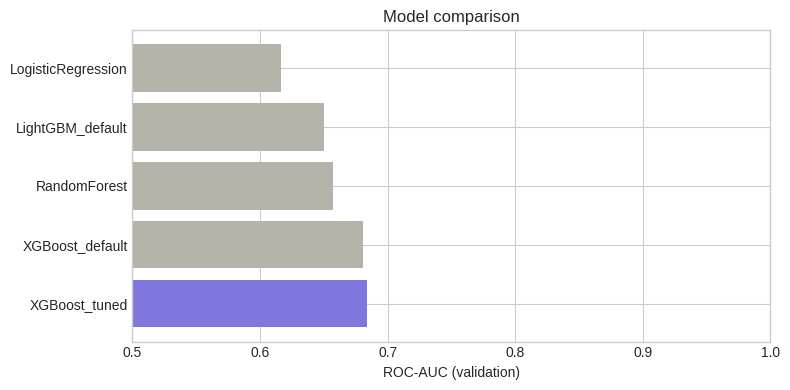

In [18]:
summary = pd.DataFrame([
    {'Model': k, 'Val AUC': v['val_auc']}
    for k, v in results.items()
]).sort_values('Val AUC', ascending=False).reset_index(drop=True)

print(summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#7F77DD' if i == 0 else '#B4B2A9' for i in range(len(summary))]
ax.barh(summary['Model'], summary['Val AUC'], color=colors)
ax.set_xlim(0.5, 1.0)
ax.set_xlabel('ROC-AUC (validation)')
ax.set_title('Model comparison')
plt.tight_layout()
plt.show()

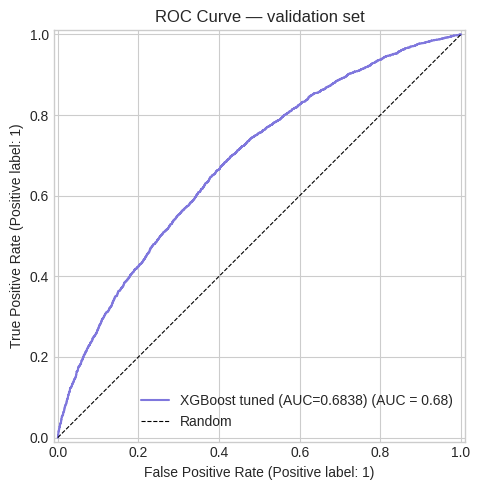

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(
    y_val, y_prob_best,
    name=f'XGBoost tuned (AUC={best_auc})',
    color='#7F77DD', ax=ax
)
ax.plot([0,1],[0,1], 'k--', linewidth=0.8, label='Random')
ax.set_title('ROC Curve — validation set')
ax.legend()
plt.tight_layout()
plt.show()

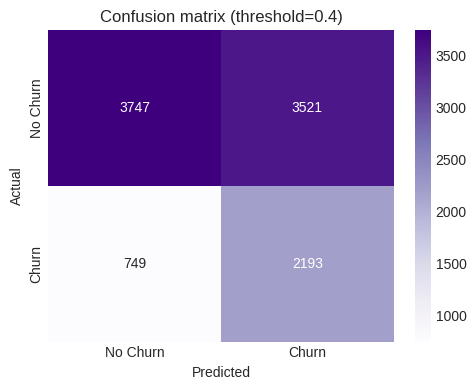

              precision    recall  f1-score   support

    No Churn       0.83      0.52      0.64      7268
       Churn       0.38      0.75      0.51      2942

    accuracy                           0.58     10210
   macro avg       0.61      0.63      0.57     10210
weighted avg       0.70      0.58      0.60     10210



In [20]:
# Use threshold 0.4 (lower = catch more churners)
THRESHOLD = 0.4
y_pred = (y_prob_best >= THRESHOLD).astype(int)

cm = confusion_matrix(y_val, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=ax,
            xticklabels=['No Churn','Churn'],
            yticklabels=['No Churn','Churn'])
ax.set_title(f'Confusion matrix (threshold={THRESHOLD})')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

print(classification_report(y_val, y_pred,
      target_names=['No Churn', 'Churn']))

In [21]:
# Run ONCE only — this is your true final performance
y_prob_holdout = best_model.predict_proba(X_holdout)[:, 1]
holdout_auc    = round(roc_auc_score(y_holdout, y_prob_holdout), 4)

print("="*40)
print(f"  HOLDOUT ROC-AUC : {holdout_auc}")
print(f"  VAL     ROC-AUC : {best_auc}")
print(f"  Gap             : {round(best_auc - holdout_auc, 4)}")
print("="*40)

  HOLDOUT ROC-AUC : nan
  VAL     ROC-AUC : 0.6838
  Gap             : nan


In [23]:
import json, os
os.makedirs('../models', exist_ok=True)

# Save model
joblib.dump(best_model, '../models/churn_pipeline.pkl')

# Save best threshold and results
meta = {
    'threshold'   : THRESHOLD,
    'val_auc'     : best_auc,
    'holdout_auc' : holdout_auc,
    'best_params' : study.best_params,
    'features'    : X_train.columns.tolist(),
    'n_features'  : X_train.shape[1]
}
with open('../models/threshold.json', 'w') as f:
    json.dump(meta, f, indent=2)

print("Model saved  → models/churn_pipeline.pkl")
print("Metadata saved → models/threshold.json")

Model saved  → models/churn_pipeline.pkl
Metadata saved → models/threshold.json
